# Воронка по каналах

`bigquery-public-data.google_analytics_sample`, серпень 2016 — серпень 2017

Числа рахуються запитами з `sql/01_funnel.sql`, вивантаження в `data/`. Гіпотези й правила аналізу зафіксовані в `hypotheses.md` до першого запиту, перевірки якості даних — у `00_data_quality.ipynb`.

Питання цього ноутбука: де ламається воронка і чи однаково для всіх каналів. Статистичних тестів тут немає — вони в окремому ноутбуці. Тут числа й таблиці, на яких ті тести рахуватимуться.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

DATA = Path('data') if Path('data').exists() else Path('..') / 'data'
if not DATA.exists():
    raise FileNotFoundError(f'Не знайдено теку з даними: {DATA.resolve()}')
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

def load(name):
    return pd.read_csv(DATA / name)

STEPS = ['viewed', 'cart', 'checkout', 'purchase']
STEP_UA = {'viewed': 'перегляд товару', 'cart': 'кошик',
           'checkout': 'checkout', 'purchase': 'покупка'}
TOTAL = 'ВСІ КАНАЛИ'

plt.rcParams.update({'figure.figsize': (9, 4.5), 'axes.spines.top': False,
                     'axes.spines.right': False, 'font.size': 10})

## 1. Склад каналів

Перевірка якості даних показала, що `youtube.com` дає 212 тисяч сесій із конверсією 0,01%. Якщо якась група `channelGrouping` тримається на одному джерелі, висновок про групу буде висновком про джерело.

In [2]:
conc = load('11b_channel_concentration.csv')
display(conc)

comp = load('11_channel_composition.csv')
display(comp[comp.channel.isin(['Social', 'Referral', 'Organic Search'])])

,channel,sessions,distinct_sources,top_source,top_source_pct
0,Organic Search,381137,13,google,59.70
1,Social,224422,33,youtube.com,94.70
2,Direct,142856,1,(direct),100.00
3,Referral,82835,200,(direct),83.10
4,Paid Search,25290,3,google,51.60
5,Affiliates,16372,1,Partners,100.00
6,Display,6259,3,dfa,90.80


,channel,source,medium,sessions,pct_of_channel
6,Organic Search,google,organic,227381,59.70
7,Organic Search,(direct),(none),147055,38.60
8,Organic Search,baidu,organic,3351,0.90
9,Organic Search,bing,organic,1526,0.40
10,Organic Search,yahoo,organic,1475,0.40
14,Referral,(direct),(none),68860,83.10
15,Referral,google.com,referral,4659,5.60
16,Referral,siliconvalley.about.com,referral,2095,2.50
17,Referral,qiita.com,referral,1811,2.20
18,Referral,blog.golang.org,referral,741,0.90


**Social — це на 94,7% youtube. У всіх висновках «канал Social» читається як «youtube».**

Виключати немає підстав: це справжній зовнішній трафік і чверть усіх сесій. Але називати його «соціальними мережами» було б неправдою.

## 2. `channelGrouping` не збігається з `trafficSource`

У складі каналів є рядки, яких за документованою логікою GA бути не мало б: `Organic Search` із `medium = '(none)'`.

In [3]:
hidden = comp[(comp.source == '(direct)') & (comp.medium == '(none)')]
display(hidden[['channel', 'sessions', 'pct_of_channel']].sort_values('sessions', ascending=False))

direct_total = int(hidden.sessions.sum())
in_direct    = int(hidden.loc[hidden.channel == 'Direct', 'sessions'].sum())
sessions_kept = int(load('13_exclusions_reconciliation.csv').sessions_kept[0])

print(f'Сесій із source = (direct):       {direct_total:,}')
print(f'  лишилися в каналі Direct:       {in_direct:,} ({100 * in_direct / direct_total:.1f}%)')
print(f'  переприписані до інших каналів: {direct_total - in_direct:,} '
      f'({100 * (direct_total - in_direct) / direct_total:.1f}%)')
print(f'Це {100 * (direct_total - in_direct) / sessions_kept:.1f}% вибірки')

,channel,sessions,pct_of_channel
7,Organic Search,147055,38.60
1,Direct,142856,100.00
14,Referral,68860,83.10
12,Paid Search,12232,48.40
4,Display,78,1.20


Сесій із source = (direct):       371,081
  лишилися в каналі Direct:       142,856 (38.5%)
  переприписані до інших каналів: 228,225 (61.5%)
Це 26.0% вибірки


**GA приписав 61,5% direct-трафіку до інших каналів. «Канал» у цьому проєкті — це `channelGrouping`, а не джерело сесії.**

Наслідок для гіпотези про атрибуцію: `channelGrouping` — це не last click, а last NON-DIRECT click. Отже метрика last-click у гіпотезі 4 означає саме це поле, і частину переприписування GA зробила до нас. Твердження гіпотези не змінюється, але очікуваний ефект слабший, ніж закладалося.

## 3. Зведення виключень

In [4]:
ex = load('13_exclusions_reconciliation.csv')
display(ex.T.rename(columns={0: 'сесій'}))

check = (int(ex.sessions_all[0]) - int(ex.excl_no_channel[0])
         - int(ex.excl_internal_google[0]) + int(ex.excl_overlap[0]))
print(f'Перевірка: {ex.sessions_all[0]:,} − {ex.excl_no_channel[0]} '
      f'− {ex.excl_internal_google[0]:,} + {ex.excl_overlap[0]} = {check:,}',
      'збігається' if check == int(ex.sessions_kept[0]) else 'не збігається')

,сесій
sessions_all,902755
excl_no_channel,120
excl_internal_google,23464
excl_overlap,0
sessions_kept,879171


Перевірка: 902,755 − 120 − 23,464 + 0 = 879,171 збігається


**879 171 сесія в аналізі, 97,4% від вихідних. Перетин двох правил виключення порожній, тому просте віднімання коректне.**

Розбіжність із перевіркою якості даних (23 506 проти 23 464) — це 42 візити, що почалися до півночі й завершилися після, тому лежать у двох денних таблицях двома рядками.

## 4. Воронка

SQL віддає лічильники без відсотків, щоб обидві форми конверсії — крок-до-кроку і наскрізна — рахувалися з одних чисел.

In [5]:
f = load('12_funnel_by_channel.csv')
f['channel'] = f.channel.fillna(TOTAL)   

long = f.melt(id_vars=['channel', 'sessions'],
              value_vars=[f'{s}_{v}' for v in ('mono', 'strict') for s in STEPS],
              var_name='col', value_name='n')
long[['step', 'version']] = long.col.str.rsplit('_', n=1, expand=True)
long = long.drop(columns='col')
long['step'] = pd.Categorical(long.step, categories=STEPS, ordered=True)
long = long.sort_values(['version', 'channel', 'step']).reset_index(drop=True)

long['cr_overall'] = 100 * long.n / long.sessions          
long['prev_n'] = long.groupby(['version', 'channel'], observed=True).n.shift(1)
long['prev_n'] = long.prev_n.fillna(long.sessions)
long['cr_step'] = 100 * long.n / long.prev_n               

mono = long[long.version == 'mono']
order = f.sort_values('sessions', ascending=False).channel

print('Конверсія крок-до-кроку, %')
display(mono.pivot(index='channel', columns='step', values='cr_step')
            .rename(columns=STEP_UA).round(2).reindex(order))
print('Наскрізна конверсія від початкової сесії, %')
display(mono.pivot(index='channel', columns='step', values='cr_overall')
            .rename(columns=STEP_UA).round(3).reindex(order))

Конверсія крок-до-кроку, %


step,перегляд товару,кошик,checkout,покупка
channel,,,,
ВСІ КАНАЛИ,14.79,40.22,42.14,51.74
Organic Search,17.17,35.71,35.08,42.00
Social,2.28,32.30,20.93,17.63
Direct,16.53,42.88,42.82,47.52
Referral,32.69,50.76,58.30,65.05
Paid Search,20.86,38.00,38.30,61.07
Affiliates,11.88,41.95,16.91,6.52
Display,24.52,37.07,40.77,61.64


Наскрізна конверсія від початкової сесії, %


step,перегляд товару,кошик,checkout,покупка
channel,,,,
ВСІ КАНАЛИ,14.79,5.95,2.51,1.30
Organic Search,17.17,6.13,2.15,0.90
Social,2.28,0.74,0.15,0.03
Direct,16.53,7.09,3.04,1.44
Referral,32.69,16.59,9.68,6.29
Paid Search,20.86,7.93,3.04,1.85
Affiliates,11.88,4.98,0.84,0.06
Display,24.52,9.09,3.71,2.29


Стартових сесій: 879,171

  → перегляд товару  втрачено  749,165  (85.21% від старту)
  → кошик            втрачено   77,724  ( 8.84% від старту)
  → checkout         втрачено   30,251  ( 3.44% від старту)
  → покупка          втрачено   10,633  ( 1.21% від старту)
  дійшли до покупки    11,398  ( 1.30%)

  вся вибірка   879,171 сесій, не дійшли до товару 85.2%
  без Social    654,749 сесій, не дійшли до товару 80.9%


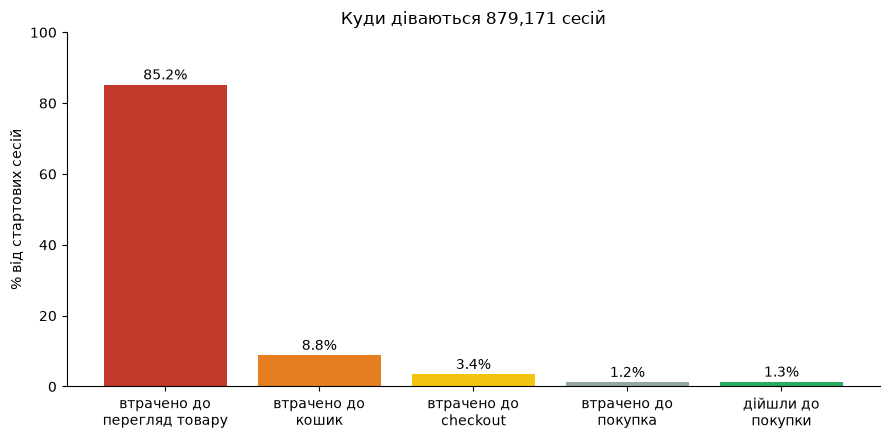

In [6]:
tot = mono[mono.channel == TOTAL].set_index('step')
sessions_all = int(f.loc[f.channel == TOTAL, 'sessions'].iloc[0])

stage_in  = [sessions_all] + [int(tot.n[s]) for s in STEPS[:-1]]
stage_out = [int(tot.n[s]) for s in STEPS]
lost = [a - b for a, b in zip(stage_in, stage_out)]

print(f'Стартових сесій: {sessions_all:,}\n')
for s, l in zip(STEPS, lost):
    print(f'  → {STEP_UA[s]:<16} втрачено {l:>8,}  ({100 * l / sessions_all:5.2f}% від старту)')
print(f'  {"дійшли до покупки":<18} {stage_out[-1]:>8,}  ({100 * stage_out[-1] / sessions_all:5.2f}%)')

soc = f[f.channel == 'Social'].iloc[0]
print()
for name, s, v in [('вся вибірка', sessions_all, int(tot.n['viewed'])),
                   ('без Social',  sessions_all - int(soc.sessions),
                                   int(tot.n['viewed']) - int(soc.viewed_mono))]:
    print(f'  {name:<12} {s:>8,} сесій, не дійшли до товару {100 * (s - v) / s:.1f}%')

fig, ax = plt.subplots()
vals = [100 * l / sessions_all for l in lost] + [100 * stage_out[-1] / sessions_all]
labels = [f'втрачено до\n{STEP_UA[s]}' for s in STEPS] + ['дійшли до\nпокупки']
bars = ax.bar(labels, vals, color=['#c0392b', '#e67e22', '#f1c40f', '#95a5a6', '#27ae60'])
ax.set_ylabel('% від стартових сесій')
ax.set_title(f'Куди діваються {sessions_all:,} сесій')
for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width() / 2, v + 1.5, f'{v:.1f}%', ha='center')
ax.set_ylim(0, 100)
plt.tight_layout()
plt.show()

**85,2% сесій закінчуються, не дійшовши до картки товару. Уся решта воронки разом втрачає 13,5%.**

Цифра не тримається на youtube: без Social вона 80,9% при 654 749 сесіях. Тобто чверть вибірки з майже нульовою активністю зсуває результат на чотири пункти, а не створює його.

Практичний наслідок: оптимізація чекауту дала б максимум 1,2 процентного пункта — уся вартість на вході. Застереження лишається: 85% рахуються від сесій, а не від людей із наміром купити.

## 5. Розкид між каналами

,"мін, крок-до-кроку","макс, крок-до-кроку","розкид, п.п.","наскрізний розкид, п.п.",наскрізне відношення макс/мін,максимум,мінімум
step,,,,,,,
перегляд товару,2.28,32.69,30.41,30.41,14.34,Referral,Social
кошик,32.30,50.76,18.46,15.86,22.53,Referral,Social
checkout,16.91,58.30,41.39,9.52,62.75,Referral,Affiliates
покупка,6.52,65.05,58.53,6.27,231.53,Referral,Affiliates


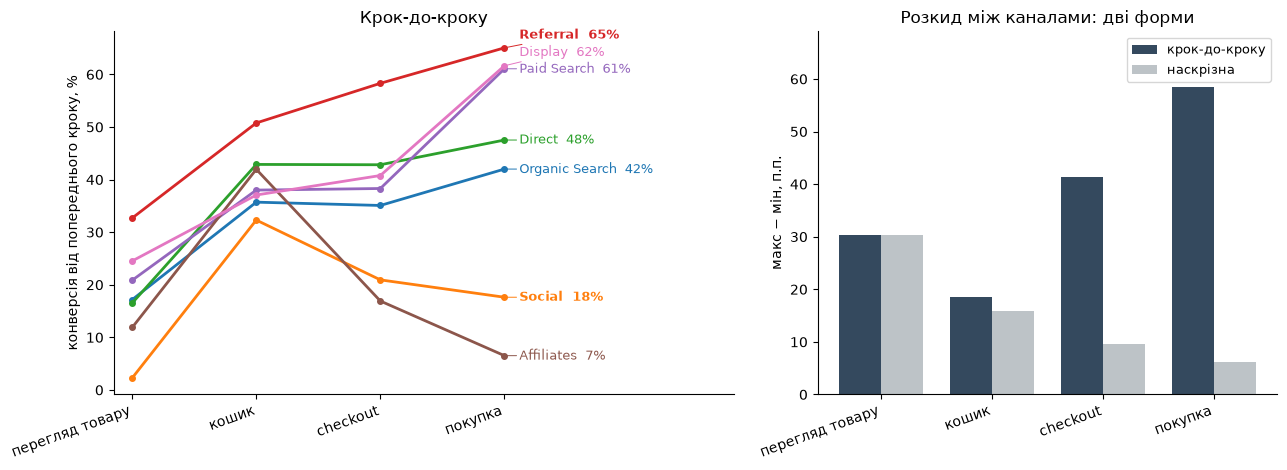

In [7]:
ch = mono[mono.channel != TOTAL]

# Пре-реєстрація вимагає дві форми конверсії, а не одну: крок-до-кроку і наскрізну.
# Наскрізна за побудовою спадає до нуля, тому її розкид у процентних пунктах
# звужується механічно — для неї дивимо ще й відношення макс/мін.
spread = pd.DataFrame({
    'мін, крок-до-кроку': ch.groupby('step', observed=True).cr_step.min(),
    'макс, крок-до-кроку': ch.groupby('step', observed=True).cr_step.max(),
})
spread['розкид, п.п.'] = spread['макс, крок-до-кроку'] - spread['мін, крок-до-кроку']
spread['наскрізний розкид, п.п.'] = (ch.groupby('step', observed=True).cr_overall.max()
                                     - ch.groupby('step', observed=True).cr_overall.min())
spread['наскрізне відношення макс/мін'] = (ch.groupby('step', observed=True).cr_overall.max()
                                           / ch.groupby('step', observed=True).cr_overall.min())
spread['максимум'] = ch.loc[ch.groupby('step', observed=True).cr_step.idxmax(), 'channel'].values
spread['мінімум']  = ch.loc[ch.groupby('step', observed=True).cr_step.idxmin(), 'channel'].values
display(spread.rename(index=STEP_UA).round(2))

# Канали в порядку розміру трафіку, кольори закріплені за каналом —
# щоб той самий канал мав той самий колір і на решті графіків проєкту.
CH_ORDER = list(f[f.channel != TOTAL].sort_values('sessions', ascending=False).channel)
COLORS = dict(zip(CH_ORDER, plt.cm.tab10.colors))
X = range(len(STEPS))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), gridspec_kw={'width_ratios': [1.35, 1]})

for channel in CH_ORDER:
    g = ch[ch.channel == channel].sort_values('step')
    axes[0].plot(X, g.cr_step, marker='o', ms=4, lw=2, color=COLORS[channel])

# Підписи каналів на кінцях ліній замість легенди: не треба зіставляти колір
# із рамкою. Якщо два кінці ближче ніж MIN_GAP, підписи розсуваються по вертикалі.
ends = (ch[ch.step == STEPS[-1]][['channel', 'cr_step']]
        .sort_values('cr_step').reset_index(drop=True))
MIN_GAP = 3.2
ys = ends.cr_step.tolist()
for i in range(1, len(ys)):
    ys[i] = max(ys[i], ys[i - 1] + MIN_GAP)

for (_, row), y in zip(ends.iterrows(), ys):
    axes[0].annotate(f'{row.channel}  {row.cr_step:.0f}%',
                     xy=(len(STEPS) - 1, row.cr_step),
                     xytext=(len(STEPS) - 0.88, y),
                     va='center', fontsize=9, color=COLORS[row.channel],
                     fontweight='bold' if row.channel in ('Referral', 'Social') else 'normal',
                     arrowprops=dict(arrowstyle='-', lw=.7, color=COLORS[row.channel],
                                     shrinkA=0, shrinkB=2))

axes[0].set_xticks(X)
axes[0].set_xticklabels([STEP_UA[s] for s in STEPS], rotation=20, ha='right')
axes[0].set_xlim(-0.15, len(STEPS) + 0.85)
axes[0].set_ylabel('конверсія від попереднього кроку, %')
axes[0].set_title('Крок-до-кроку')

w = 0.38
pos = [i - w / 2 for i in X]
axes[1].bar(pos, spread['розкид, п.п.'], width=w, color='#34495e', label='крок-до-кроку')
axes[1].bar([p + w for p in pos], spread['наскрізний розкид, п.п.'], width=w,
            color='#bdc3c7', label='наскрізна')
axes[1].set_xticks(list(X))
axes[1].set_xticklabels([STEP_UA[s] for s in STEPS], rotation=20, ha='right')
axes[1].set_ylabel('макс − мін, п.п.')
axes[1].set_title('Розкид між каналами: дві форми')
axes[1].legend(fontsize=9)
axes[1].set_ylim(0, spread['розкид, п.п.'].max() * 1.18)

plt.tight_layout()
plt.show()

**Дві пре-реєстровані форми конверсії дають протилежні відповіді. Описові метрики питання не вирішують — його вирішує формальний критерій, і він рахується окремо.**

Крок-до-кроку розкид розширюється донизу воронки: 30,4 → 18,5 → 41,4 → 58,5 п.п. Наскрізний, навпаки, звужується: 30,4 → 15,9 → 9,5 → 6,3 п.п. А відношення макс/мін на наскрізній конверсії росте різко: 14× → 23× → 63× → 232×.

Три виміри однієї величини, три різні напрямки — і жоден із них не є пре-реєстрованим критерієм. Причина розбіжності зрозуміла: наскрізна конверсія за побудовою спадає до нуля, тому її розкид у процентних пунктах мусить звужуватися незалежно від поведінки каналів, а розкид крок-до-кроку роздувається там, де базові рівні високі (на останньому кроці конверсії 42–65% проти 2–33% на першому).

Саме через це порогом у `hypotheses.md` стоїть Cramer's V із бутстреп-інтервалом на різницю між першим і останнім кроком: V нормалізує на базовий рівень і не залежить від розміру вибірки. Оголошувати результат за розкидом у пунктах означало б підмінити пре-реєстровану метрику зручнішою.

Що описові числа все ж кажуть однозначно: спадають донизу воронки лише Affiliates і Social, решта п'ять каналів зростають. Тобто розкид на останньому кроці створюють два аутсайдери проти п'яти схожих між собою каналів, і в цих двох — 9 і 61 покупка. Хай яким буде V, цю обставину доведеться враховувати у висновку.

## 6. Строга версія як контроль

Рішення про монотонну воронку зафіксоване в `hypotheses.md` до аналізу; строга рахується як контроль.

In [8]:
cmp = (long[long.channel == TOTAL]
       .pivot(index='step', columns='version', values='n')
       .loc[STEPS])
cmp.columns = ['монотонна', 'строга']
cmp['різниця'] = cmp['монотонна'] - cmp['строга']
cmp['строга у % від монотонної'] = 100 * cmp['строга'] / cmp['монотонна']
display(cmp.rename(index=STEP_UA).round(1))

bad = long.pivot_table(index=['channel', 'step'], columns='version', values='n', observed=True)
print('Монотонна менша за строгу (має бути 0):', int((bad['mono'] < bad['strict']).sum()))

,монотонна,строга,різниця,строга у % від монотонної
step,,,,
перегляд товару,130006,121921,8085,93.80
кошик,52282,43697,8585,83.60
checkout,22031,17042,4989,77.40
покупка,11398,9078,2320,79.60


Монотонна менша за строгу (має бути 0): 0


**Строга версія втрачає 20% покупок — тих, у яких пропущено крок угорі воронки.**

Це не помилка однієї з версій: строга відповідає на питання «скільки сесій пройшли всі кроки з повним записом подій», монотонна — «скільки сесій купили». Для питання «де ламається воронка» правильна монотонна.

## 7. Конфаунд монотонності

`hypotheses.md` фіксує обмеження: монотонність дозаписує крок «перегляд товару» лише тим сесіям, які дійшли далі, тому цей крок виміряний точніше для покупців. Обіцяно було виміряти по каналах.

,channel,sessions_with_hits,pct_no_view,purchase_sessions,buyers_no_view,pct_buyers_no_view
0,ВСІ КАНАЛИ,879171,86.13,11398,2097,18.40
1,Organic Search,381137,83.58,3443,556,16.15
2,Social,224422,97.96,61,21,34.43
3,Direct,142856,85.25,2060,597,28.98
4,Referral,82835,69.47,5213,823,15.79
5,Paid Search,25290,79.98,469,77,16.42
6,Affiliates,16372,88.65,9,0,0.00
7,Display,6259,76.66,143,23,16.08


Канали зі 100+ покупками: від 15.8% (Referral) до 29.0% (Direct)


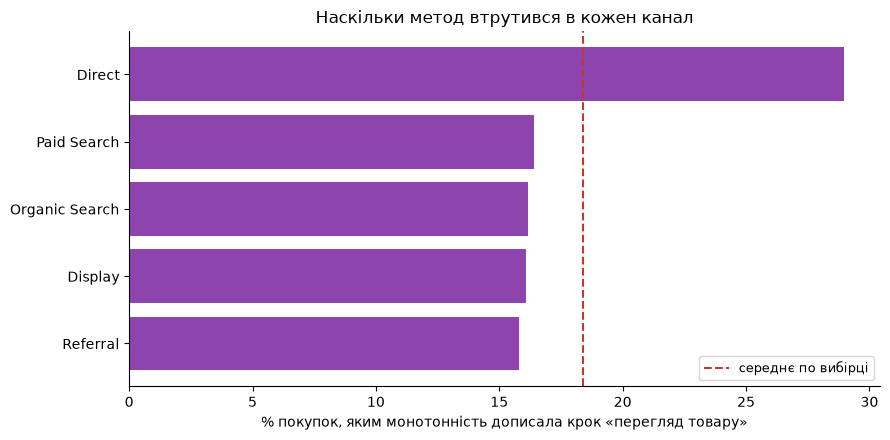

In [9]:
cf = load('14_monotonic_confound.csv')
cf['channel'] = cf.channel.fillna(TOTAL)
display(cf[['channel', 'sessions_with_hits', 'pct_no_view',
            'purchase_sessions', 'buyers_no_view', 'pct_buyers_no_view']])

sub = (cf[(cf.channel != TOTAL) & (cf.purchase_sessions >= 100)]
       .sort_values('pct_buyers_no_view'))
print(f'Канали зі 100+ покупками: від {sub.pct_buyers_no_view.min():.1f}% '
      f'({sub.channel.iloc[0]}) до {sub.pct_buyers_no_view.max():.1f}% ({sub.channel.iloc[-1]})')

fig, ax = plt.subplots()
ax.barh(sub.channel, sub.pct_buyers_no_view, color='#8e44ad')
ax.axvline(float(cf.loc[cf.channel == TOTAL, 'pct_buyers_no_view'].iloc[0]),
           color='#c0392b', ls='--', lw=1.5, label='середнє по вибірці')
ax.set_xlabel('% покупок, яким монотонність дописала крок «перегляд товару»')
ax.set_title('Наскільки метод втрутився в кожен канал')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

**Метод втрутився нерівномірно: 15,8% покупок у Referral проти 29,0% у Direct.**

Отже, розкид на першому кроці не є чистою поведінковою величиною, і висновок про нього має містити цю поправку. Social (34,4%) і Affiliates не інтерпретуються — 61 і 9 покупок.

## 8. Referral складається з двох різних популяцій

In [10]:
SRC_TYPE = {'приховані direct': 'джерело затерте', 'сире джерело': 'джерело збережене'}
HIDDEN, KEPT = 'джерело затерте', 'джерело збережене'

split = load('15b_funnel_by_direct_sourced.csv').rename(columns={'bucket': 'source_type'})
split['source_type'] = split.source_type.map(SRC_TYPE)
display(split.pivot(index='channel', columns='source_type', values='cr_pct'))

ret = load('15_direct_source_vs_channel.csv')
display(ret[['channel', 'pct_direct_sourced', 'pct_return_direct',
             'pct_return_rest', 'pct_referral_path']])

source_type,джерело затерте,джерело збережене
channel,,
Affiliates,NaN,0.06
Direct,1.44,NaN
Display,NaN,2.28
Organic Search,0.90,0.91
Paid Search,1.85,1.86
Referral,7.46,0.55
Social,NaN,0.03


,channel,pct_direct_sourced,pct_return_direct,pct_return_rest,pct_referral_path
0,Organic Search,38.60,20.70,20.70,0.00
1,Direct,100.00,25.30,NaN,0.00
2,Referral,83.10,55.60,19.60,100.00
3,Paid Search,48.40,36.70,38.70,0.00
4,Display,1.20,35.90,70.40,0.00
5,Affiliates,0.00,NaN,23.70,NaN
6,Social,0.00,NaN,6.90,NaN


**Конверсія Referral 6,3% тримається цілком на сесіях із затертим джерелом: 7,46% проти 0,55% у справжніх рефералів.**

Тобто реферальний трафік у звичайному розумінні (qiita.com, blog.golang.org) конвертує вдвічі гірше за середнє по сайту. В `Organic Search` і `Paid Search` той самий розріз різниці не дає — там це просто дивність у полі `source`.

In [11]:
paths = load('16_referral_path_hidden_direct.csv')
land  = load('16b_hidden_direct_landing.csv')
display(paths.head(4))
display(land.head(5))

root     = int(paths.loc[paths.referral_path == '/', 'sessions'].iloc[0])
hidden_n = int(split.loc[(split.channel == 'Referral')
                         & (split.source_type == HIDDEN), 'sessions'].iloc[0])
print(f'Кореневий шлях: {root:,} з {hidden_n:,} сесій ({100 * root / hidden_n:.1f}%)')

,referral_path,sessions,purchases,cr_pct,pct_returning
0,/,67163,5114,7.61,55.20
1,/offer/2145,1064,18,1.69,86.50
2,/Rewards/Products/Details.aspx,185,4,2.16,15.70
3,/pagead/ads,84,0,0.00,51.20


,landing_page,sessions
0,/home,52031
1,/home-2,4615
2,/signin.html,3304
3,/basket.html,1504
4,/store.html,642


Кореневий шлях: 67,163 з 68,860 сесій (97.5%)


In [12]:
GRP  = {'бакет': HIDDEN, 'решта': 'решта вибірки'}
REST = 'решта вибірки'

net = load('17_hidden_direct_network.csv'); net['grp'] = net.grp.map(GRP)
cn  = load('17b_hidden_direct_concentration.csv'); cn['grp'] = cn.grp.map(GRP)

cols = ['net_domain', 'sessions', 'purchases', 'cr_pct']
print('Топ мереж серед сесій із затертим джерелом:')
display(net[net.grp == HIDDEN].head(8)[cols])
print('Топ мереж у решті вибірки:')
display(net[net.grp == REST].head(8)[cols])
display(cn)

ns_h = int(net[(net.grp == HIDDEN) & (net.net_domain == '(not set)')].sessions.iloc[0])
ns_r = int(net[(net.grp == REST)   & (net.net_domain == '(not set)')].sessions.iloc[0])
t_h  = int(cn.loc[cn.grp == HIDDEN, 'sessions'].iloc[0])
t_r  = int(cn.loc[cn.grp == REST,   'sessions'].iloc[0])
print(f'networkDomain = (not set): серед затертих {100 * ns_h / t_h:.1f}%, '
      f'у решті {100 * ns_r / t_r:.1f}%')

Топ мереж серед сесій із затертим джерелом:


,net_domain,sessions,purchases,cr_pct
0,(not set),53771,3780,7.03
1,comcast.net,5119,428,8.36
2,verizon.net,1348,203,15.06
3,unknown.unknown,1252,94,7.51
4,rr.com,862,99,11.48
5,comcastbusiness.net,666,53,7.96
6,sbcglobal.net,421,37,8.79
7,optonline.net,335,45,13.43


Топ мереж у решті вибірки:


,net_domain,sessions,purchases,cr_pct
15,(not set),184783,2766,1.50
16,unknown.unknown,141672,304,0.21
17,comcast.net,22926,500,2.18
18,rr.com,13704,267,1.95
19,ttnet.com.tr,13192,1,0.01
20,verizon.net,11975,264,2.20
21,comcastbusiness.net,9058,250,2.76
22,hinet.net,7134,11,0.15


,grp,visitors,sessions,purchases,sessions_per_visitor,buyers,buyers_3plus,pct_purchases_from_3plus
0,решта вибірки,667852,810311,6262,1.21,5514,126,9.50
1,джерело затерте,38336,68860,5136,1.80,4439,115,8.10


networkDomain = (not set): серед затертих 78.1%, у решті 22.8%


**Дві версії походження перевірені й обидві спростовані. Ці сесії лишаються в аналізі, з перевіркою на чутливість у тестах.**

*Розірваний платіжний потік* — сесії стартували б з `/payment.html`, а стартують з `/home` у 75,6%. *Внутрішній трафік компанії* — мережі побутові (comcast, verizon, cox), і концентрації немає: 38 336 відвідувачів, покупці з трьома й більше замовленнями дають 8,1% покупок проти 9,5% у решті вибірки, тобто ця група розподілена ширше за звичайний трафік.

Лишається 38 тисяч звичайних покупців, які повертаються частіше за середнє (1,8 сесії проти 1,21). Аномальне тільки те, що обидва поля походження затерті одночасно: `source` дорівнює `(direct)`, `networkDomain` дорівнює `(not set)` у 78,1% проти 22,8% у решті — це артефакт обробки датасету, а не властивість людей. Далі копати нема куди: хоста реферера в даних немає.

На сесії із затертим джерелом припадає 45,1% усіх покупок вибірки, тому всі висновки по Referral рахуються двічі — з ними і без них. Це 68 860 сесій, у яких `channelGrouping = 'Referral'`, `source = '(direct)'` і `medium = '(none)'`; кореневий шлях `referralPath = '/'` дає 97,5% із них. Далі всюди беруться саме ці межі, бо на них побудовані запити 15b, 17 і 17b.

## Рішення за підсумками побудови воронки

Доповнюють рішення, ухвалені за підсумками перевірки якості даних. Формулювань гіпотез не змінюють.

| Рішення | Впливає на |
|---|---|
| «Канал Social» у всіх висновках читається як «youtube» (94,7% групи) | гіпотези 1, 3, 4 |
| «Канал» визначається як `channelGrouping`, а не як джерело сесії: 61,5% direct-трафіку GA переприписала | усі |
| Сесії Referral із затертим джерелом (68 860, 45,1% покупок) лишаються в аналізі; висновки по Referral перевіряються на чутливість | 1, 3, 4 |
| Правило `*.google.com` не переглядається попри 5 014 сесій із `networkDomain = google.com`; вони отримують ОКРЕМУ перевірку на чутливість — не спільну із сесіями Referral із затертим джерелом, бо лежать за їхніми межами й мають іншу природу. Покупок серед них нуль | 1, 3, 4 |
| Поріг 100 покупок для таблиці конфаунду — рішення ПОСТ-ФАКТУМ, після перегляду даних, і стосується лише цієї описової таблиці. Тести гіпотез 1 і 2 лишаються на пре-реєстрованих 100 сесіях, тобто жоден канал з них не виключається | 1, 2 |
| Метрика конфаунду **розширена, не замінена**: пре-реєстровано `pct_no_view`, додано `pct_buyers_no_view`. Друга показує саме ставку дозапису, тому в тексті спираюся на неї — але додана вона після того, як стали видні дані, і обидві лишаються в таблиці | 1, 2 |

## Що це дало гіпотезам

- **Канали різняться вгорі воронки, а не внизу** — не вирішено описово: крок-до-кроку розкид розширюється (30,4 → 58,5 п.п.), наскрізний звужується (30,4 → 6,3 п.п.). Вирішує Cramer's V із бутстреп-інтервалом.
- **Рейтинг каналів визначає конверсія, а не чек** — під загрозою: конверсія Referral належить сесіям із затертим джерелом, а не каналу. CV рахується у двох варіантах.
- **Останній клік недооцінює канали відкриття** — ефект послаблений до перевірки: last-click тут насправді last non-direct click, GA уже переприписала 228 тисяч сесій. Зріз по користувачах із 2+ сесіями складатиметься переважно з цієї ж групи (1,8 сесії проти 1,21).
- **Мобільні сесії відвалюються на пізніших кроках, ніж десктопні** — тут не перевіряється: розріз по `device.deviceCategory` у наступному ноутбуці, разом із повторним заміром конфаунду по пристроях.